In [58]:
from random import sample, randint

In [61]:
def monty_hall(change_door=False, n_sim=1, display=True):
    counter = 0
    for _ in range(n_sim):
        values = ['c', 'c', 'c']
        car, goat1, goat2 = sample([0, 1, 2], 3)
        values[car] = 'm'
        first_choice = randint(0, 2)
        
        if first_choice == car:
            second_choice = sample([goat1, goat2], 1).pop()
        elif first_choice == goat1:
            second_choice = goat2
        else:
            second_choice = goat1
    
        if change_door:
            first_choice = ({0, 1, 2} - {first_choice, second_choice}).pop()
    
        counter += car == first_choice

    return counter / n_sim        

In [75]:
print(monty_hall(False, 1, False))

0.0


In [79]:
print(monty_hall(True, 1, False))

1.0


In [165]:
from matplotlib.pyplot import hist, show, grid, bar, legend

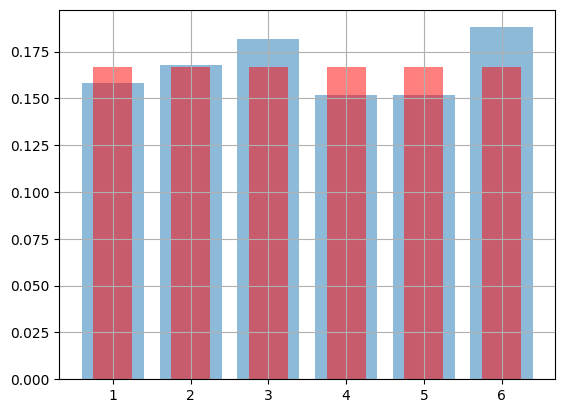

In [166]:
data = [randint(1, 6) for _ in range(500)]
bin_edges = [k + 0.5 for k in range(7)]
hist(data, bins=bin_edges, density=True, rwidth=0.8, alpha=0.5)

values = [k+1 for k in range(6)]
theoretical_prob = [1 / 6 for _ in range(6)]
bar(values, theoretical_prob, color='red', width=0.5, alpha=0.5)

grid()
show()

In [167]:
from scipy.stats import binom

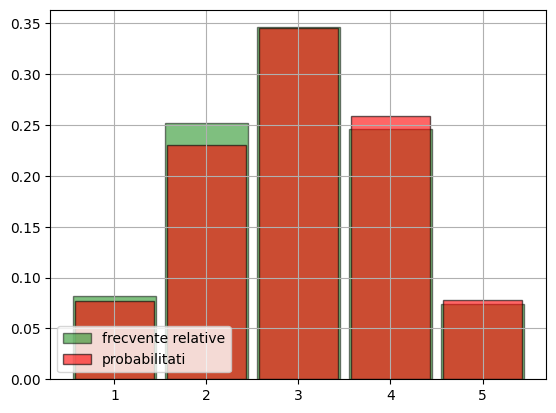

In [168]:
n = 5
p = 0.6
x = binom.rvs(n, p, size=1000)
bin_edges = [k+0.5 for k in range(6)]
hist(x, bins=bin_edges, density = True, rwidth = 0.9, color = 'green', edgecolor = 'black',
    alpha = 0.5, label = 'frecvente relative')

distribution = dict([(i,binom.pmf(i, 5, 6/10)) for i in range(1,6)])
bar(list(distribution.keys()), list(distribution.values()), width = 0.85, color = 'red', edgecolor = 'black',
        alpha= 0.6, label = 'probabilitati')

legend(loc = 'lower left')
grid()
show()

In [174]:
probability = sum((k > 2 and k <= 5) for k in x) / 1000
theoretical = binom.cdf(5, 1000, 6 / 10) - binom.cdf(2, 1000, 6 / 10)
print(probability)

0.663
